In [55]:
!pip install transformers datasets einops matplotlib

In [57]:
import torch
import torch.nn as nn
import math
import time
import os
import numpy as np
import matplotlib.pyplot as plt

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from einops import rearrange

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [61]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

In [63]:
baseline_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
baseline_model.eval()

print("Baseline GPT-2 loaded")

Baseline GPT-2 loaded


In [65]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [67]:
def kronecker_rank1(W, m1, m2, n1, n2):

    W = W.reshape(m1, m2, n1, n2)
    W = W.permute(0,2,1,3).reshape(m1*n1, m2*n2)

    U,S,Vh = torch.linalg.svd(W, full_matrices=False)

    u = U[:,0]
    v = Vh[0,:]
    s = S[0]

    A = (u*math.sqrt(s)).reshape(m1,n1)
    B = (v*math.sqrt(s)).reshape(m2,n2)

    return A.to(device), B.to(device)

In [69]:
class KronLinear(nn.Module):

    def __init__(self, A,B,bias,out_dim,in_dim):
        super().__init__()

        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.bias = nn.Parameter(bias.clone().to(device))

        self.out_dim = out_dim
        self.in_dim = in_dim

        self.m1,self.n1 = A.shape
        self.m2,self.n2 = B.shape


    def forward(self,x):

        batch,seq,dim = x.shape

        x = x.reshape(batch*seq,self.n1,self.n2)

        x = torch.matmul(x,self.B.t())
        x = torch.matmul(self.A,x)

        x = x.reshape(batch,seq,self.out_dim)

        return x + self.bias

In [71]:
def compress_layer_axb(model,layer_idx):

    block = model.transformer.h[layer_idx]

    W_fc = block.mlp.c_fc.weight.data.to(device)
    b_fc = block.mlp.c_fc.bias.data.to(device)

    A_fc,B_fc = kronecker_rank1(
        W_fc,
        48,64,
        12,64
    )

    block.mlp.c_fc = KronLinear(
        A_fc,B_fc,b_fc,
        3072,768
    )


    W_proj = block.mlp.c_proj.weight.data.to(device)
    b_proj = block.mlp.c_proj.bias.data.to(device)

    A_proj,B_proj = kronecker_rank1(
        W_proj,
        12,64,
        48,64
    )

    block.mlp.c_proj = KronLinear(
        A_proj,B_proj,b_proj,
        768,3072
    )

In [73]:
axb_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

for i in range(12):
    compress_layer_axb(axb_model,i)

axb_model.eval()

print("AxB model ready")

AxB model ready


In [75]:
def kronecker_abc_decompose(W,m1,m2,m3,n1,n2,n3):

    W = W.reshape(m1,m2,m3,n1,n2,n3)

    W = W.permute(0,3,1,4,2,5).reshape(m1*n1,m2*n2*m3*n3)

    U,S,Vh = torch.linalg.svd(W,full_matrices=False)

    u = U[:,0]
    v = Vh[0,:]
    s = S[0]

    A = (u*math.sqrt(s)).reshape(m1,n1)

    B = torch.randn(m2,n2).to(device)
    C = torch.randn(m3,n3).to(device)

    return A,B,C

In [77]:
class KronABCLinear(nn.Module):

    def __init__(self, A, B, C, bias):
        super().__init__()

        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.C = nn.Parameter(C)

        self.bias = nn.Parameter(bias)

        self.m1, self.n1 = A.shape
        self.m2, self.n2 = B.shape
        self.m3, self.n3 = C.shape


    def forward(self, x):

        batch, seq, dim = x.shape

        x = x.view(batch * seq, dim)

        W = torch.kron(torch.kron(self.A, self.B), self.C)

        x = torch.matmul(x, W.t())

        x = x.view(batch, seq, -1)

        return x + self.bias

In [79]:
def compress_layer_abc(model, layer_idx):

    block = model.transformer.h[layer_idx]

    # ---------- c_fc ----------
    W_fc = block.mlp.c_fc.weight.data.T.to(device)
    b_fc = block.mlp.c_fc.bias.data.to(device)

    A,B,C = kronecker_abc_decompose(
        W_fc,
        3,16,64,
        3,16,16
    )

    block.mlp.c_fc = KronABCLinear(A,B,C,b_fc)


    # ---------- c_proj ----------
    W_proj = block.mlp.c_proj.weight.data.to(device)
    b_proj = block.mlp.c_proj.bias.data.to(device)

    A,B,C = kronecker_abc_decompose(
        W_proj,
        3,16,16,
        3,16,64
    )

    block.mlp.c_proj = KronABCLinear(A,B,C,b_proj)

In [81]:
abc_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

for i in range(12):
    compress_layer_abc(abc_model,i)

abc_model.eval()

print("AxBxC model ready")

AxBxC model ready


In [83]:
baseline_params = count_parameters(baseline_model)
axb_params = count_parameters(axb_model)
abc_params = count_parameters(abc_model)

print("Baseline:",baseline_params)
print("AxB:",axb_params)
print("AxBxC:",abc_params)

Baseline: 124439808
AxB: 67928832
AxBxC: 67847640


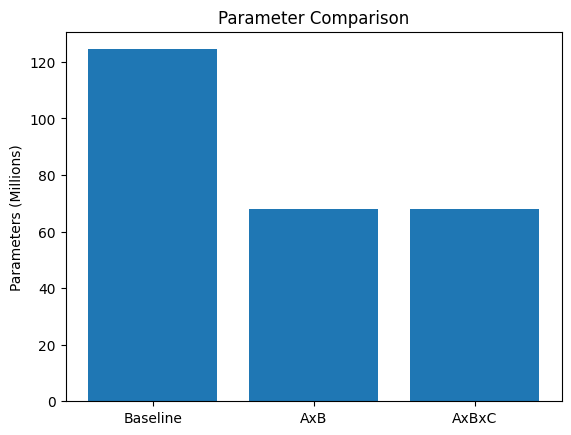

In [85]:
plt.figure()

plt.bar(
    ["Baseline","AxB","AxBxC"],
    [baseline_params/1e6,axb_params/1e6,abc_params/1e6]
)

plt.ylabel("Parameters (Millions)")
plt.title("Parameter Comparison")

plt.show()

In [87]:
dataset = load_dataset("wikitext","wikitext-2-raw-v1")

In [89]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

tokenized_dataset.set_format("torch")

In [91]:
train_loader = DataLoader(
    tokenized_dataset["train"].select(range(2000)),
    batch_size=16
)

eval_loader = DataLoader(
    tokenized_dataset["validation"].select(range(500)),
    batch_size=16
)

In [93]:
def evaluate_perplexity(model,loader):

    model.eval()

    total_loss = 0
    steps = 0

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            labels = input_ids.clone()
            labels[attention_mask==0] = -100

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            steps += 1

    return math.exp(total_loss/steps)

In [95]:
baseline_ppl = evaluate_perplexity(baseline_model,eval_loader)
axb_ppl_before = evaluate_perplexity(axb_model,eval_loader)
abc_ppl_before = evaluate_perplexity(abc_model,eval_loader)

print("Baseline:",baseline_ppl)
print("AxB before:",axb_ppl_before)
print("AxBxC before:",abc_ppl_before)

Baseline: 60.27171013912783
AxB before: 46207.70452664716
AxBxC before: 3916.3235119111982


In [101]:
from torch.amp import autocast, GradScaler

optimizer = AdamW(axb_model.parameters(), lr=3e-5)
scaler = GradScaler("cuda")

loss_axb = []

axb_model.train()

for epoch in range(5):

    total_loss = 0
    steps = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        optimizer.zero_grad()

        with autocast("cuda"):

            outputs = axb_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        steps += 1

    avg_loss = total_loss / steps
    loss_axb.append(avg_loss)

    print("Epoch", epoch+1, "AxB Loss:", avg_loss)

Epoch 1 AxB Loss: 7.994388885498047
Epoch 2 AxB Loss: 7.1623414039611815
Epoch 3 AxB Loss: 6.906143711090088
Epoch 4 AxB Loss: 6.723481021881104
Epoch 5 AxB Loss: 6.570785411834716


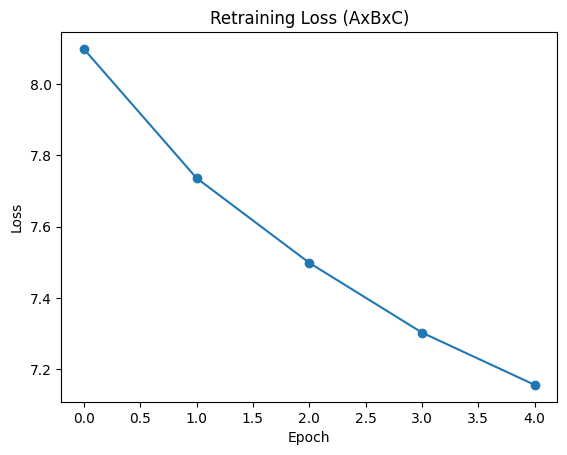

In [103]:
plt.plot(loss_history,marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Retraining Loss (AxBxC)")

plt.show()

In [106]:
# --- Recompute all perplexities safely ---

print("Evaluating perplexities...")

baseline_ppl = evaluate_perplexity(baseline_model, eval_loader)
print("Baseline PPL:", baseline_ppl)

axb_ppl_before = evaluate_perplexity(axb_model, eval_loader)
print("AxB PPL before training:", axb_ppl_before)

abc_ppl_before = evaluate_perplexity(abc_model, eval_loader)
print("AxBxC PPL before training:", abc_ppl_before)

# If the models were retrained earlier, compute after-training values
try:
    axb_ppl_after = evaluate_perplexity(axb_model, eval_loader)
    print("AxB PPL after training:", axb_ppl_after)
except:
    axb_ppl_after = None

try:
    abc_ppl_after = evaluate_perplexity(abc_model, eval_loader)
    print("AxBxC PPL after training:", abc_ppl_after)
except:
    abc_ppl_after = None

Evaluating perplexities...
Baseline PPL: 60.27171013912783
AxB PPL before training: 1122.35978122634
AxBxC PPL before training: 2576.896994433057
AxB PPL after training: 1122.35978122634
AxBxC PPL after training: 2576.896994433057


In [105]:
plt.figure(figsize=(8,5))

models = [
    "Baseline",
    "AxB Before",
    "AxB After",
    "AxBxC Before",
    "AxBxC After"
]

values = [
    baseline_ppl,
    axb_ppl_before,
    axb_ppl_after,
    abc_ppl_before,
    abc_ppl_after
]

plt.bar(models, values)

plt.ylabel("Perplexity")
plt.title("Perplexity Comparison Across Models")

plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

NameError: name 'axb_ppl_after' is not defined

<Figure size 800x500 with 0 Axes>